<a href="https://colab.research.google.com/github/EduardoKenzoHayashi/CN-Lobosco/blob/main/Atividade1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

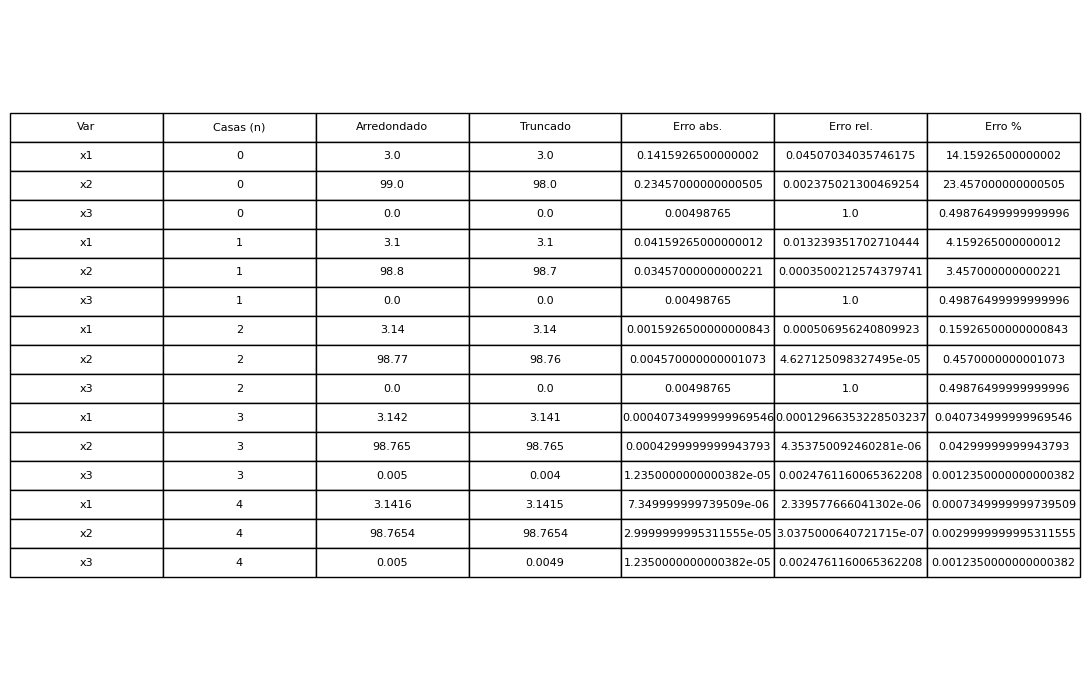

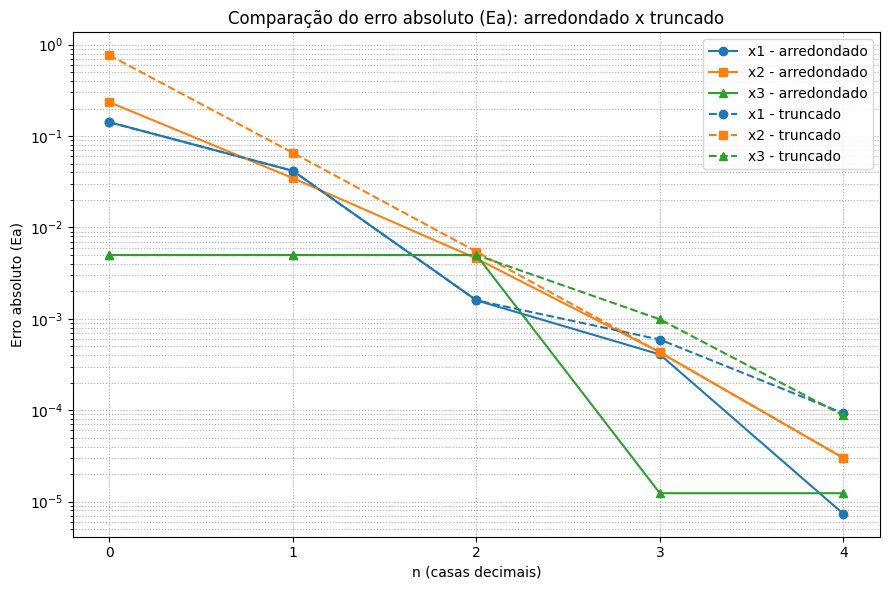

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
def truncar(numero, casas):
    # Calcula o fator que desloca a vírgula decimal.
    fator = 10 ** casas

    # Trunca o número deslocado e devolve a vírgula à posição original.
    return math.trunc(numero * fator) / fator

def err_abs(x,n):
  return abs(x-round(x,n))

def err_rel(err,x):
  return err/abs(x)

def err_per(err):
  return err*100

x1 = 3.14159265
x2 = 98.76543
x3 = 0.00498765
linhas = []
for n in range(0,5):
  linhas.append(["x1", n, round(x1,n), truncar(x1,n), err_abs(x1,n), err_rel(err_abs(x1,n), x1), err_per(err_abs(x1,n))])
  linhas.append(["x2", n, round(x2,n), truncar(x2,n), err_abs(x2,n), err_rel(err_abs(x2,n), x2), err_per(err_abs(x2,n))])
  linhas.append(["x3", n, round(x3,n), truncar(x3,n), err_abs(x3,n), err_rel(err_abs(x3,n), x3), err_per(err_abs(x3,n))])
#fim for
colunas = [
    "Var", "Casas (n)", "Arredondado",
    "Truncado", "Erro abs.", "Erro rel.", "Erro %"
]

fig, ax = plt.subplots(figsize=(11, 7))
ax.axis('off')

tabela = ax.table(cellText=linhas, colLabels=colunas, loc='center', cellLoc='center')
tabela.auto_set_font_size(False)
tabela.set_fontsize(8)
tabela.scale(1, 1.4)
plt.tight_layout()
plt.show()
# --- Gráfico de Ea em função de n (escala log no eixo y) ---

# Função auxiliar para calcular o erro absoluto do valor TRUNCADO.
# Repara que é igual à ideia do err_abs, mas comparando x com truncar(x, n)
# em vez de comparar x com round(x, n).
def err_abs_trunc(x, n):
    return abs(x - truncar(x, n))

# Lista com os valores de n usados na tabela (0, 1, 2, 3, 4).
ns = list(range(0, 5))

# --- Erros absolutos usando ARREDONDAMENTO (round) ---
# Para cada n, calcula o Ea de x1 comparando x1 com round(x1, n).
ea_x1_round = [err_abs(x1, n) for n in ns]
# Mesma lógica para x2.
ea_x2_round = [err_abs(x2, n) for n in ns]
# Mesma lógica para x3.
ea_x3_round = [err_abs(x3, n) for n in ns]

# --- Erros absolutos usando TRUNCAMENTO (truncar) ---
# Para cada n, calcula o Ea de x1 comparando x1 com truncar(x1, n).
ea_x1_trunc = [err_abs_trunc(x1, n) for n in ns]
# Mesma lógica para x2.
ea_x2_trunc = [err_abs_trunc(x2, n) for n in ns]
# Mesma lógica para x3.
ea_x3_trunc = [err_abs_trunc(x3, n) for n in ns]

# Cria uma nova figura (janela do gráfico) com tamanho 9x6 polegadas.
plt.figure(figsize=(9, 6))

# --- Curvas do arredondamento (linha cheia) ---
# Plota Ea de x1 (arredondado) em função de n, com escala log no eixo Y.
#sesmiology é usado quando os dados têm uma diferença muito grande de escala entre os valores, e um gráfico linear normal esconderia essa diferença.
plt.semilogy(ns, ea_x1_round, marker='o', linestyle='-', color='tab:blue', label='x1 - arredondado')
# Plota Ea de x2 (arredondado) em função de n.
plt.semilogy(ns, ea_x2_round, marker='s', linestyle='-', color='tab:orange', label='x2 - arredondado')
# Plota Ea de x3 (arredondado) em função de n.
plt.semilogy(ns, ea_x3_round, marker='^', linestyle='-', color='tab:green', label='x3 - arredondado')

# --- Curvas do truncamento (linha tracejada, mesma cor da variável correspondente) ---
# Plota Ea de x1 (truncado) em função de n. Usa a mesma cor de x1 arredondado,
# mas com linha tracejada ('--'), para ficar fácil comparar visualmente o par.
plt.semilogy(ns, ea_x1_trunc, marker='o', linestyle='--', color='tab:blue', label='x1 - truncado')
# Plota Ea de x2 (truncado) em função de n.
plt.semilogy(ns, ea_x2_trunc, marker='s', linestyle='--', color='tab:orange', label='x2 - truncado')
# Plota Ea de x3 (truncado) em função de n.
plt.semilogy(ns, ea_x3_trunc, marker='^', linestyle='--', color='tab:green', label='x3 - truncado')

# Define o rótulo do eixo X.
plt.xlabel("n (casas decimais)")

# Define o rótulo do eixo Y.
plt.ylabel("Erro absoluto (Ea)")

# Define o título do gráfico, deixando claro que é uma comparação.
plt.title("Comparação do erro absoluto (Ea): arredondado x truncado")

# Garante que o eixo X mostre exatamente os valores inteiros de n (0,1,2,3,4).
plt.xticks(ns)

# Mostra a legenda com todas as 6 curvas (3 arredondadas + 3 truncadas).
plt.legend()

# Adiciona grade pontilhada nas linhas principais e secundárias
# (facilita muito a leitura em escala logarítmica).
plt.grid(True, which="both", ls=":")

# Ajusta os espaçamentos automaticamente para nada ficar cortado.
plt.tight_layout()

# Renderiza o gráfico na tela.
plt.show()

Olhando os gráficos, arrendodar gera um erro menor ou igual ao erro absoluto gerado por valores truncados

In [2]:
def erroa(refer, aprox):
  return abs(refer - aprox)

In [3]:
r = 0.8*(10 ** (-3))
L = 0.2
mi = 3.5 * (10 ** (-3))
p = 1200
Q = (math.pi*(r**4)*p)/(8*mi*L)
print(Q)

2.757420751950813e-07


In [4]:
rtrunc = truncar(0.8,1)
rarr = round(0.8,1)
Qtrunc = (math.pi*((rtrunc*(10**-3))**4)*p)/(8*mi*L)
Qarr = (math.pi*((rarr*(10**-3))**4)*p)/(8*mi*L)
print(f"Q com r truncado {Qtrunc}")
print(f"Q com r arredondado {Qarr}")
print(f"O erro absoluto do Q com r truncado seria {erroa(Q, Qtrunc)}")
print(f"O erro absoluto do Q com r proximado seria {erroa(Q, Qarr)}")


Q com r truncado 2.757420751950813e-07
Q com r arredondado 2.757420751950813e-07
O erro absoluto do Q com r truncado seria 0.0
O erro absoluto do Q com r proximado seria 0.0


In [5]:
mitrunc = truncar(mi , 3)
miarr = round(mi,3)

Qtrunc = (math.pi*(r**4)*p)/(8*mitrunc*L)
Qarr = (math.pi*(r**4)*p)/(8*miarr*L)
print(f"Q com mi truncado {Qtrunc}")
print(f"Q com mi arredondado {Qarr}")

print(f"O erro absoluto do Q com mi truncado seria {erroa(Q, Qtrunc)}")
print(f"O erro absoluto do Q com mi proximado seria {erroa(Q, Qarr)}")


Q com mi truncado 3.2169908772759484e-07
Q com mi arredondado 2.4127431579569616e-07
O erro absoluto do Q com mi truncado seria 4.5957012532513556e-08
O erro absoluto do Q com mi proximado seria 3.446775939938513e-08


In [6]:
ptrunc = 12
parr = 12
Qarr = (math.pi*(r**4)*parr)/(8*mi*L)
Qtrunc = (math.pi*(r**4)*ptrunc)/(8*mi*L)
print(f"Q com delta p truncado {Qtrunc}")
print(f"Q com delta p arredondado {Qarr}")

print(f"O erro absoluto do Q com delta p truncado seria {erroa(Q, Qtrunc)}")
print(f"O erro absoluto do Q com delta p proximado seria {erroa(Q, Qarr)}")


Q com delta p truncado 2.7574207519508133e-09
Q com delta p arredondado 2.7574207519508133e-09
O erro absoluto do Q com delta p truncado seria 2.7298465444313047e-07
O erro absoluto do Q com delta p proximado seria 2.7298465444313047e-07


In [7]:
Qarr = (math.pi*((rarr*(10**-3))**4)*parr)/(8*miarr*L)
Qtrunc = (math.pi*((rtrunc*(10**-3))**4)*ptrunc)/(8*mitrunc*L)
print(f"Q com tudo truncado {Qtrunc}")
print(f"Q com tudo arredondado {Qarr}")

print(f"O erro absoluto do Q com tudo truncado seria {erroa(Q, Qtrunc)}")
print(f"O erro absoluto do Q com tudo proximado seria {erroa(Q, Qarr)}")

Q com tudo truncado 3.216990877275949e-09
Q com tudo arredondado 2.4127431579569616e-09
O erro absoluto do Q com tudo truncado seria 2.7252508431780536e-07
O erro absoluto do Q com tudo proximado seria 2.7332933203712433e-07


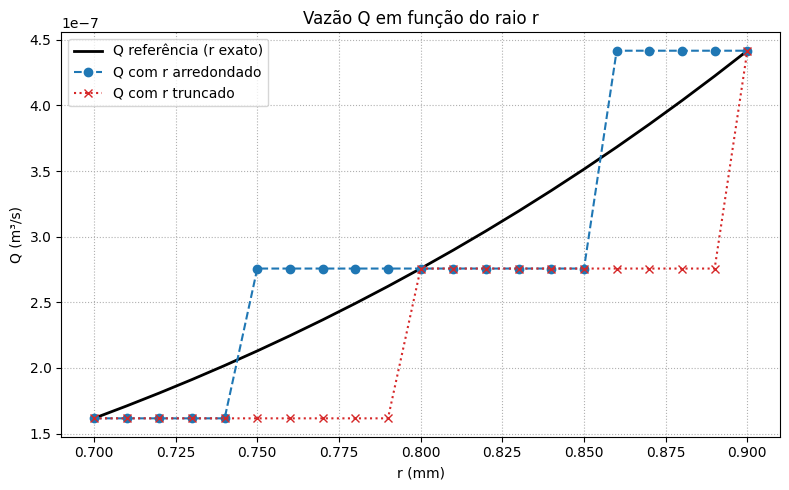

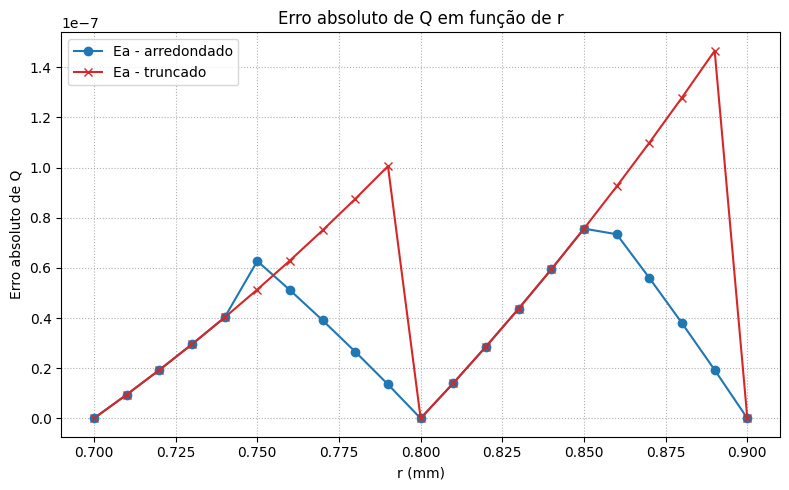

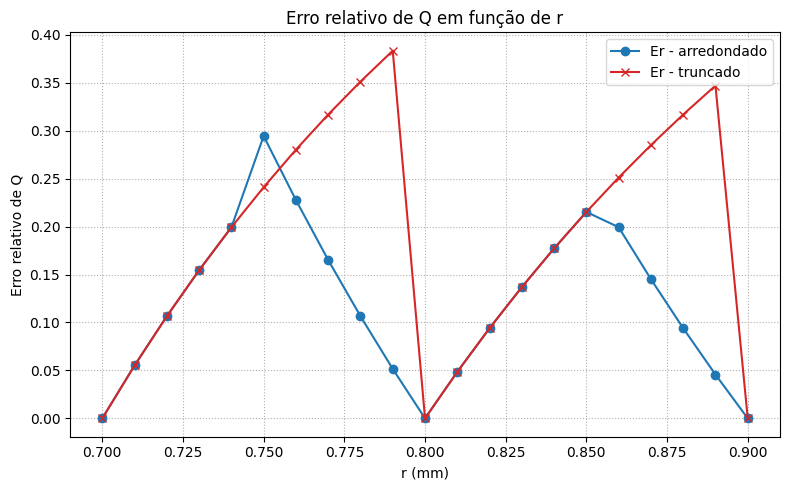

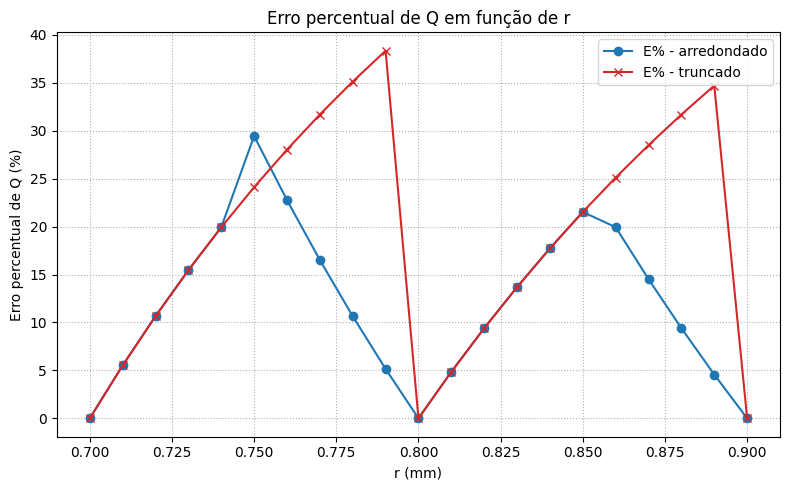

In [8]:
import math
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Função de truncamento (já usada nos itens anteriores)
# ---------------------------------------------------------
def truncar(numero, casas):
    fator = 10 ** casas
    return math.trunc(numero * fator) / fator

# ---------------------------------------------------------
# Função que calcula a vazão Q pela Lei de Hagen–Poiseuille
# Q = (pi * r^4 * dp) / (8 * mu * L)
# IMPORTANTE: r deve estar em METROS aqui dentro.
# ---------------------------------------------------------
def calc_Q(r_m, dp, mu, L):
    return (math.pi * r_m**4 * dp) / (8 * mu * L)

# ---------------------------------------------------------
# Parâmetros fixos do problema
# ---------------------------------------------------------
L = 0.20          # comprimento do tubo, em metros
mu = 3.5e-3       # viscosidade dinâmica, em Pa.s
dp = 1200         # diferença de pressão, em Pa

# ---------------------------------------------------------
# Faixa de raios a variar: de 0,70 mm a 0,90 mm, passo 0,01 mm
# ---------------------------------------------------------
r_mm = np.arange(0.70, 0.90 + 1e-9, 0.01)  # raios em milímetros

# Listas para guardar os resultados de cada raio
lista_r          = []
lista_Q_ref      = []
lista_Q_round    = []
lista_Q_trunc    = []
lista_Ea_round   = []
lista_Ea_trunc   = []
lista_Er_round   = []
lista_Er_trunc   = []
lista_Ep_round   = []
lista_Ep_trunc   = []

# ---------------------------------------------------------
# Loop principal: para cada raio da faixa, calcula:
# - Q de referência (raio exato, sem arredondar/truncar)
# - Q com raio arredondado para 1 casa decimal (em mm)
# - Q com raio truncado para 1 casa decimal (em mm)
# - os erros absoluto, relativo e percentual de cada aproximação
# ---------------------------------------------------------
for r in r_mm:
    # --- Raio de referência (exato) convertido para metros ---
    r_ref_m = r / 1000.0

    # --- Raio arredondado para 1 casa decimal (ainda em mm), depois convertido para metros ---
    r_round_mm = round(r, 1)
    r_round_m = r_round_mm / 1000.0

    # --- Raio truncado para 1 casa decimal (ainda em mm), depois convertido para metros ---
    r_trunc_mm = truncar(r, 1)
    r_trunc_m = r_trunc_mm / 1000.0

    # --- Calcula Q para os três casos usando a função de Poiseuille ---
    Q_ref   = calc_Q(r_ref_m,   dp, mu, L)
    Q_round = calc_Q(r_round_m, dp, mu, L)
    Q_trunc = calc_Q(r_trunc_m, dp, mu, L)

    # --- Erro absoluto: |Q_referencia - Q_aproximado| ---
    Ea_round = abs(Q_ref - Q_round)
    Ea_trunc = abs(Q_ref - Q_trunc)

    # --- Erro relativo: Ea dividido pelo valor de referência ---
    Er_round = Ea_round / abs(Q_ref)
    Er_trunc = Ea_trunc / abs(Q_ref)

    # --- Erro percentual: erro relativo multiplicado por 100 ---
    Ep_round = Er_round * 100
    Ep_trunc = Er_trunc * 100

    # --- Guarda tudo nas listas para usar depois nos gráficos ---
    lista_r.append(r)
    lista_Q_ref.append(Q_ref)
    lista_Q_round.append(Q_round)
    lista_Q_trunc.append(Q_trunc)
    lista_Ea_round.append(Ea_round)
    lista_Ea_trunc.append(Ea_trunc)
    lista_Er_round.append(Er_round)
    lista_Er_trunc.append(Er_trunc)
    lista_Ep_round.append(Ep_round)
    lista_Ep_trunc.append(Ep_trunc)

# ===========================================================
# GRÁFICO 1: Q em função de r (referência, arredondado, truncado)
# ===========================================================

# Cria uma nova figura (janela do gráfico) com tamanho 8x5 polegadas.
plt.figure(figsize=(8, 5))

# Plota a curva de Q "de referência", ou seja, calculado com o raio exato,
# sem nenhum arredondamento ou truncamento.
# - color="black" e linewidth=2 destacam essa curva como a "correta"/base de comparação.
plt.plot(lista_r, lista_Q_ref,
          label="Q referência (r exato)",
          color="black",
          linewidth=2)

# Plota a curva de Q calculado com o raio ARREDONDADO para 1 casa decimal.
# - linestyle="--" (tracejado) e marker="o" (bolinha) ajudam a diferenciar
#   visualmente essa curva da curva de referência.
plt.plot(lista_r, lista_Q_round,
          label="Q com r arredondado",
          color="tab:blue",
          linestyle="--",
          marker="o")

# Plota a curva de Q calculado com o raio TRUNCADO para 1 casa decimal.
# - linestyle=":" (pontilhado) e marker="x" deixam essa curva visualmente
#   diferente das outras duas.
plt.plot(lista_r, lista_Q_trunc,
          label="Q com r truncado",
          color="tab:red",
          linestyle=":",
          marker="x")

# Define o rótulo do eixo X (o raio, em milímetros).
plt.xlabel("r (mm)")

# Define o rótulo do eixo Y (a vazão Q, em metros cúbicos por segundo).
plt.ylabel("Q (m³/s)")

# Define o título do gráfico.
plt.title("Vazão Q em função do raio r")

# Mostra a legenda com os nomes definidos em cada "label" acima.
plt.legend()

# Adiciona uma grade pontilhada para facilitar a leitura dos valores nos eixos.
plt.grid(True, ls=":")

# Ajusta automaticamente os espaçamentos da figura para nada ficar cortado.
plt.tight_layout()

# Renderiza o gráfico na tela.
plt.show()


# ===========================================================
# GRÁFICO 2: Erro absoluto de Q em função de r
# ===========================================================

# Cria uma nova figura para o gráfico de erro absoluto.
plt.figure(figsize=(8, 5))

# Plota o erro absoluto (Ea) de Q quando o raio foi ARREDONDADO,
# em função do raio original (não arredondado) usado em cada ponto.
plt.plot(lista_r, lista_Ea_round,
          label="Ea - arredondado",
          color="tab:blue",
          marker="o")

# Plota o erro absoluto (Ea) de Q quando o raio foi TRUNCADO,
# em função do raio original usado em cada ponto.
plt.plot(lista_r, lista_Ea_trunc,
          label="Ea - truncado",
          color="tab:red",
          marker="x")

# Define o rótulo do eixo X (raio em mm).
plt.xlabel("r (mm)")

# Define o rótulo do eixo Y (erro absoluto de Q, mesma unidade de Q: m³/s).
plt.ylabel("Erro absoluto de Q")

# Define o título do gráfico.
plt.title("Erro absoluto de Q em função de r")

# Mostra a legenda distinguindo arredondado x truncado.
plt.legend()

# Adiciona grade pontilhada para facilitar a leitura.
plt.grid(True, ls=":")

# Ajusta os espaçamentos automaticamente.
plt.tight_layout()

# Renderiza o gráfico na tela.
plt.show()


# ===========================================================
# GRÁFICO 3: Erro relativo de Q em função de r
# ===========================================================

# Cria uma nova figura para o gráfico de erro relativo.
plt.figure(figsize=(8, 5))

# Plota o erro relativo (Er = Ea / Q_referência) para o caso ARREDONDADO.
# O erro relativo é adimensional (não tem unidade), pois é uma razão entre
# duas grandezas de mesma unidade (Ea e Q).
plt.plot(lista_r, lista_Er_round,
          label="Er - arredondado",
          color="tab:blue",
          marker="o")

# Plota o erro relativo (Er) para o caso TRUNCADO.
plt.plot(lista_r, lista_Er_trunc,
          label="Er - truncado",
          color="tab:red",
          marker="x")

# Define o rótulo do eixo X (raio em mm).
plt.xlabel("r (mm)")

# Define o rótulo do eixo Y (erro relativo, sem unidade).
plt.ylabel("Erro relativo de Q")

# Define o título do gráfico.
plt.title("Erro relativo de Q em função de r")

# Mostra a legenda distinguindo arredondado x truncado.
plt.legend()

# Adiciona grade pontilhada para facilitar a leitura.
plt.grid(True, ls=":")

# Ajusta os espaçamentos automaticamente.
plt.tight_layout()

# Renderiza o gráfico na tela.
plt.show()


# ===========================================================
# GRÁFICO 4: Erro percentual de Q em função de r
# ===========================================================

# Cria uma nova figura para o gráfico de erro percentual.
plt.figure(figsize=(8, 5))

# Plota o erro percentual (E% = Er * 100) para o caso ARREDONDADO.
# É basicamente o mesmo gráfico do erro relativo, só que em escala de 0 a 100(%).
plt.plot(lista_r, lista_Ep_round,
          label="E% - arredondado",
          color="tab:blue",
          marker="o")

# Plota o erro percentual (E%) para o caso TRUNCADO.
plt.plot(lista_r, lista_Ep_trunc,
          label="E% - truncado",
          color="tab:red",
          marker="x")

# Define o rótulo do eixo X (raio em mm).
plt.xlabel("r (mm)")

# Define o rótulo do eixo Y (erro percentual de Q, em %).
plt.ylabel("Erro percentual de Q (%)")

# Define o título do gráfico.
plt.title("Erro percentual de Q em função de r")

# Mostra a legenda distinguindo arredondado x truncado.
plt.legend()

# Adiciona grade pontilhada para facilitar a leitura.
plt.grid(True, ls=":")

# Ajusta os espaçamentos automaticamente.
plt.tight_layout()

# Renderiza o gráfico na tela.
plt.show()

In [11]:
orig = [121.7 , 120.4 , 122.1 , 119.8 , 121.2 , 120.9 , 122.4 , 121.0 , 120.2 , 121.5]
arre = []
trunc = []
def media(lista, qtd):
  soma = 0
  for i in lista:
    soma += i
  return soma / qtd

def minimo(lista):
  min = lista[0]
  for i in lista:
    if(i < min):
      min = i
  return min

def maximo(lista):
  max = lista[0]
  for i in lista:
    if(i > max):
      max = i
  return max

def amp(lista):
  mini = minimo(lista)
  maxi = maximo(lista)
  return abs(maxi - mini)

def desviop(lista, n):
  med = media(lista, n)
  desvio = 0
  for i  in lista:
    desvio += ((med - i) ** 2)
  desvio = (desvio / (n - 1)) ** (1/2)
  return desvio

for o in orig:
  arr = round(o , 0)
  arre.append(arr)
  trun = truncar(o , 0)
  trunc.append(trun)

medo = media(orig , 10)
mino = minimo(orig)
maxo = maximo(orig)
ampo = amp(orig)
dpo = desviop(orig , 10)

print(f"A média original é {medo}")
print(f"O mínimo original é {mino}")
print(f"O máximo original é {maxo}")
print(f"A amplitude original é {ampo}")
print(f"O desvio padrão original é {dpo}")

medarre = media(arre , 10)
mina = minimo(arre)
maxa = maximo(arre)
ampa = amp(arre)
dpa = desviop(arre , 10)

print(f"A média arredondada é {medarre}")
print(f"O mínimo arredondado é {mina}")
print(f"O máximo arredondado é {maxa}")
print(f"A amplitude arredondada é {ampa}")
print(f"O desvio padrão arredondado é {dpa}")

medtrunc = media(trunc , 10)
mint = minimo(trunc)
maxt = maximo(trunc)
ampt = amp(trunc)
dtp = desviop(trunc , 10)

print(f"A média truncada é {medtrunc}")
print(f"O minimo truncado é {mint}")
print(f"O máximo truncado é {maxt}")
print(f"A amplitude truncada é {ampt}")
print(f"O desvio padrão truncado é {dtp}")





A média original é 121.12
O mínimo original é 119.8
O máximo original é 122.4
A amplitude original é 2.6000000000000085
O desvio padrão original é 0.8337332373793856
A média arredondada é 121.1
O mínimo arredondado é 120.0
O máximo arredondado é 122.0
A amplitude arredondada é 2.0
O desvio padrão arredondado é 0.8755950357709131
A média truncada é 120.7
O minimo truncado é 119.0
O máximo truncado é 122.0
A amplitude truncada é 3.0
O desvio padrão truncado é 0.9486832980505138


In [12]:
def cebs(referencia, aproximado):
  return abs(referencia - aproximado)
eaarr = cebs (medo,medarre)
erarr = err_rel (eaarr, medo)
eparr = err_per (erarr)
print(f"O erro absoluto da média arredondada é {eaarr}")
print(f"O erro relativo da média arredondada é {erarr}")
print(f"O erro percentual da média arredondada é {eparr}")

eatrunc = cebs (medo, medtrunc)
ertrunc = err_rel (eatrunc, medo)
eptrunc = err_per (ertrunc)
print(f"O erro absoluto da média truncada é {eatrunc}")
print(f"O erro relativo da média truncada é {ertrunc}")
print(f"O erro percentual da média truncada é {eptrunc}")

O erro absoluto da média arredondada é 0.020000000000010232
O erro relativo da média arredondada é 0.0001651254953765706
O erro percentual da média arredondada é 0.01651254953765706
O erro absoluto da média truncada é 0.4200000000000017
O erro relativo da média truncada é 0.003467635402906223
O erro percentual da média truncada é 0.3467635402906223


TypeError: 'str' object is not callable

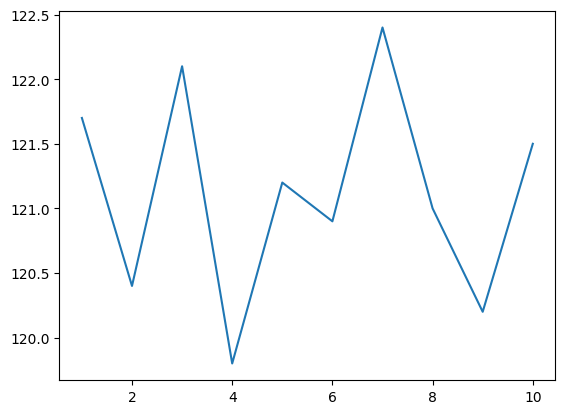

In [26]:
#há 10 valores, logo x varia de 1 at´pe 10
x = np.arange(1, 11, 1)
#gráfico das medições original
plt.plot(x , orig)
plt.xlabel = "Medição"
plt.ylabel = "Pressão"
plt.title("Valores originais")
plt.show()

#gráfico das medições arredondadas
plt.plot(x, arre)
plt.xlabel = "Medição"
plt.ylabel = "Pressão"
plt.title("Meu Título Customizado")
plt.show()

#gráfico dos valores truncados
plt.plot(x, trunc)
plt.xlabel = "Medição"
plt.ylabel = "Pressão"
plt.title("valores truncados")
plt.show()

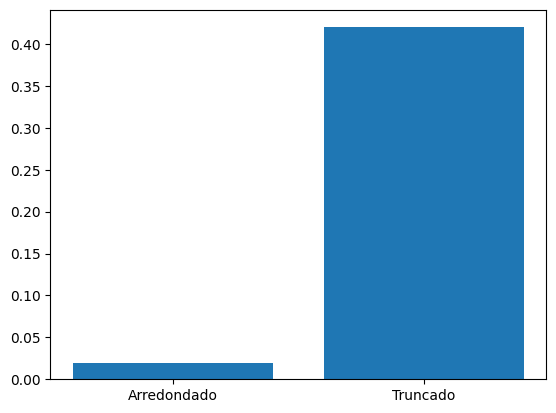

In [19]:

categorias = [ "Arredondado","Truncado" ]
erros_abs = [eaarr, eatrunc]
plt.bar(categorias,erros_abs)
plt.show()

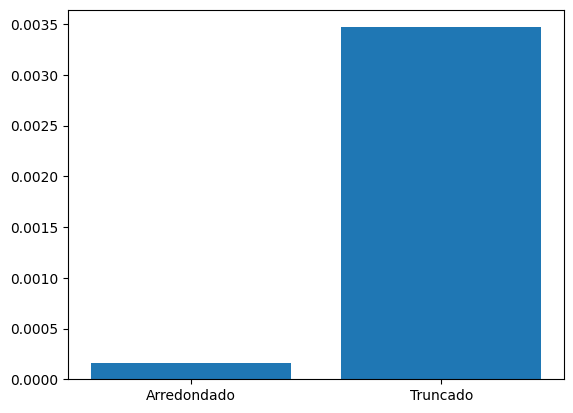

In [22]:
erros_rel = [erarr, ertrunc]
plt.bar(categorias, erros_rel)
plt.title = "Arredondados"
plt.show()